# Milestone 1: Meeting Transcript Efficiency Analyzer

**Team Members:** Rahul Reddy Asam, Ashruth Reddy Gangula, Rakesh Kumar Reddy Dodda

**Date:** 2026-02-08

**Course:** CAP5771 - Intro to Data Science

## 1. Problem Formulation

### Problem Type
We are solving multiple interconnected problems:
- **Classification**: Classify sentences as "decision," "action item," or "general discussion"
- **Exploration**: Discover patterns like decision timing and redundancy
- **Decision Support**: Help managers assess meeting effectiveness

### Central Question
Are meetings actually producing decisions and clear action items, or are they mostly repetitive discussion?

### Why This Question Matters

Meetings consume significant time in professional and academic environments [1]. Poor meetings lead to:
- Wasted labor hours
- Unclear responsibilities
- Lack of objective measurement of effectiveness

Despite transcripts being readily available, objective analysis of meeting quality is rarely performed [1].

### What Makes This Project Unique

Unlike sentiment analysis approaches, this project focuses on **information quality** [1]:
- Measures actual decisions made vs. repetitive discussion
- Produces interpretable metrics (decision density, redundancy score, action item clarity)
- Output is actionable, not a black-box score

### Data Sources

We obtained the AMI Meeting Corpus via the Hugging Face `datasets` library [1]:
- 108,502 training utterances
- 13,098 validation utterances
- 12,643 test utterances
- **Total:** 134,243 utterances across 171 meetings

The corpus contains:
- Meeting IDs to group conversations
- Speaker IDs for attribution
- Timestamps for temporal analysis
- Utterance text for content analysis

### Required Variables [1]

- **Text of each utterance**: Essential for classifying content as decisions, action items, or general discussion
- **Meeting ID**: Groups utterances into coherent meeting sessions
- **Speaker IDs**: Identifies who said what
- **Timestamps**: Enables temporal analysis and redundancy detection

These variables directly enable measurement of our three core metrics: decision density, redundancy score, and action item clarity [1].

### Success Criteria [1]

A meaningful output for our Meeting Transcript Efficiency Analyzer shows:
- **Low decision density** → Few decisions made during the meeting
- **High redundancy** → Repetitive discussion of the same topics
- **Poorly defined action items** → Unclear next steps or responsibilities

These metrics clearly indicate an inefficient meeting that could benefit from restructuring.

### Stakeholders & Benefits [1]

**Who will use this:**
- Team leads and managers
- Instructors facilitating group projects
- Meeting organizers

**How they benefit:**
- Identify meetings needing restructuring or elimination
- Improve productivity without monitoring individuals
- Objective evidence instead of subjective opinions

## 2. Data Acquisition

### Data Source Selection

We selected the **AMI Meeting Corpus** for this project:
- Contains real workplace meeting transcripts with manual annotations
- Publicly available and structured for research use
- Manual transcriptions ensure high accuracy for text analysis

### Acquisition Method

We used the Hugging Face `datasets` library to programmatically obtain the data:

### Data Acquisition Code (Already Executed)

**Note:** This code was executed once to download and extract the AMI corpus. 
The extracted data is stored in `data/` folder (171 transcript files).
**Do not re-run** to avoid re-downloading ~12GB of data.

In [ ]:
import os
from datasets import load_dataset

# Check if data already exists
data_folder = 'data'
transcript_files = [f for f in os.listdir(data_folder) if f.endswith('_transcript.txt')]

if len(transcript_files) > 0:
    print(f"✓ Data already exists: {len(transcript_files)} transcript files found in data/ folder")
    print("Skipping download to avoid re-downloading ~12GB dataset")
else:
    # Load AMI corpus (Individual Headset Microphone configuration)
    print("Loading AMI dataset...")
    dataset = load_dataset("edinburghcstr/ami", "ihm")
    
    # Remove audio column (we only need text)
    dataset = dataset.remove_columns(['audio'])
    
    # Display dataset structure
    print("\n=== Dataset Statistics ===")
    print(f"Training set: {len(dataset['train']):,} utterances")
    print(f"Validation set: {len(dataset['validation']):,} utterances")
    print(f"Test set: {len(dataset['test']):,} utterances")
    print(f"Total: {len(dataset['train']) + len(dataset['validation']) + len(dataset['test']):,} utterances")

### Data Extraction Results

We successfully extracted **171 transcript files** (one per meeting) with the following structure:
- **Meeting IDs**: Unique identifiers for each meeting
- **Speaker IDs**: Attribution for each utterance
- **Timestamps**: Start and end times for temporal analysis
- **Utterance text**: The actual spoken words for content analysis

### Storage Approach

Due to the size of the corpus (~12GB with audio), we:
1. Removed audio files to reduce memory footprint
2. Extracted text-only transcripts into local `.txt` files
3. Organized files by meeting ID for easy access

Total extracted data: ~9MB of text across 171 meetings.

## 3. Data Acquisition II: Database Schema

### Schema Design

We designed a relational database to store meeting transcripts:

**Tables:**
- `meetings`: Meeting metadata (meeting_id, corpus_source, date, duration)
- `speakers`: Speaker information (speaker_id, meeting_id, speaker_label)
- `utterances`: Individual utterances (utterance_id, meeting_id, speaker_id, text, start_time, end_time)
- `topic_segments`: Topic boundaries (segment_id, meeting_id, start_time, end_time, topic_label)

*Note: Database schema visualization and implementation code to be added.*

In [ ]:
import sqlite3

# Create database connection
conn = sqlite3.connect('../data/meeting_transcripts.db')
cursor = conn.cursor()

# Create meetings table
cursor.execute('''
CREATE TABLE IF NOT EXISTS meetings (
    meeting_id TEXT PRIMARY KEY,
    corpus_source TEXT,
    date TEXT,
    duration_seconds INTEGER
)
''')

# Create speakers table
cursor.execute('''
CREATE TABLE IF NOT EXISTS speakers (
    speaker_id INTEGER PRIMARY KEY AUTOINCREMENT,
    meeting_id TEXT,
    speaker_label TEXT,
    FOREIGN KEY (meeting_id) REFERENCES meetings(meeting_id)
)
''')

# Create utterances table
cursor.execute('''
CREATE TABLE IF NOT EXISTS utterances (
    utterance_id INTEGER PRIMARY KEY AUTOINCREMENT,
    meeting_id TEXT,
    speaker_id INTEGER,
    text TEXT,
    start_time REAL,
    end_time REAL,
    FOREIGN KEY (meeting_id) REFERENCES meetings(meeting_id),
    FOREIGN KEY (speaker_id) REFERENCES speakers(speaker_id)
)
''')

conn.commit()
print("Database schema created successfully!")

# Verify tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(f"\nTables created: {cursor.fetchall()}")

conn.close()

## 4. Data Exploration

### Overview

We explore the 171 extracted transcript files to understand:
- Distribution of meetings and utterances
- Speaker participation patterns
- Meeting length characteristics
- Data quality issues

In [3]:
import os

# Navigate up one level from code/ to project root, then into data/
data_folder = '../data'

# Verify the path exists
if not os.path.exists(data_folder):
    print(f"Error: {data_folder} not found")
    print(f"Current directory: {os.getcwd()}")
else:
    transcript_files = [f for f in os.listdir(data_folder) if f.endswith('_transcript.txt')]
    print(f"Total transcript files: {len(transcript_files)}")
    print(f"\nSample files:")
    for i, file in enumerate(transcript_files[:5]):
        print(f"  {i+1}. {file}")

Total transcript files: 171

Sample files:
  1. EN2001a_transcript.txt
  2. EN2001b_transcript.txt
  3. EN2001d_transcript.txt
  4. EN2001e_transcript.txt
  5. EN2002a_transcript.txt


In [ ]:
# Load and analyze one example transcript file
example_file = transcript_files[0] if transcript_files else None

if example_file:
    file_path = os.path.join(data_folder, example_file)
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    print(f"=== Example File: {example_file} ===")
    print(f"Total utterances: {len(lines)}")
    print(f"\nFirst 5 utterances:")
    for i, line in enumerate(lines[:5]):
        # Format: speaker_id|timestamp|text
        parts = line.strip().split('|')
        if len(parts) >= 3:
            print(f"  Speaker: {parts[0]}, Time: {parts[1]}, Text: {parts[2][:50]}...")

In [4]:
# Analyze all transcript files
meeting_stats = []

for file in transcript_files:
    file_path = os.path.join(data_folder, file)
    meeting_id = file.replace('_transcript.txt', '')
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    speakers = set()
    for line in lines:
        parts = line.strip().split('|')
        if len(parts) >= 3:
            speakers.add(parts[0])
    
    meeting_stats.append({
        'meeting_id': meeting_id,
        'num_utterances': len(lines),
        'num_speakers': len(speakers)
    })

# Create DataFrame
import pandas as pd
df_stats = pd.DataFrame(meeting_stats)

print("=== Descriptive Statistics ===\n")
print(df_stats.describe())
print(f"\n=== Overall Statistics ===")
print(f"Total meetings: {len(df_stats)}")
print(f"Total utterances: {df_stats['num_utterances'].sum():,}")
print(f"Average utterances per meeting: {df_stats['num_utterances'].mean():.1f}")
print(f"Average speakers per meeting: {df_stats['num_speakers'].mean():.1f}")

=== Descriptive Statistics ===

       num_utterances  num_speakers
count      171.000000    171.000000
mean       785.046784      3.988304
std        385.396951      0.216613
min        113.000000      3.000000
25%        529.500000      4.000000
50%        711.000000      4.000000
75%       1008.000000      4.000000
max       2419.000000      5.000000

=== Overall Statistics ===
Total meetings: 171
Total utterances: 134,243
Average utterances per meeting: 785.0
Average speakers per meeting: 4.0


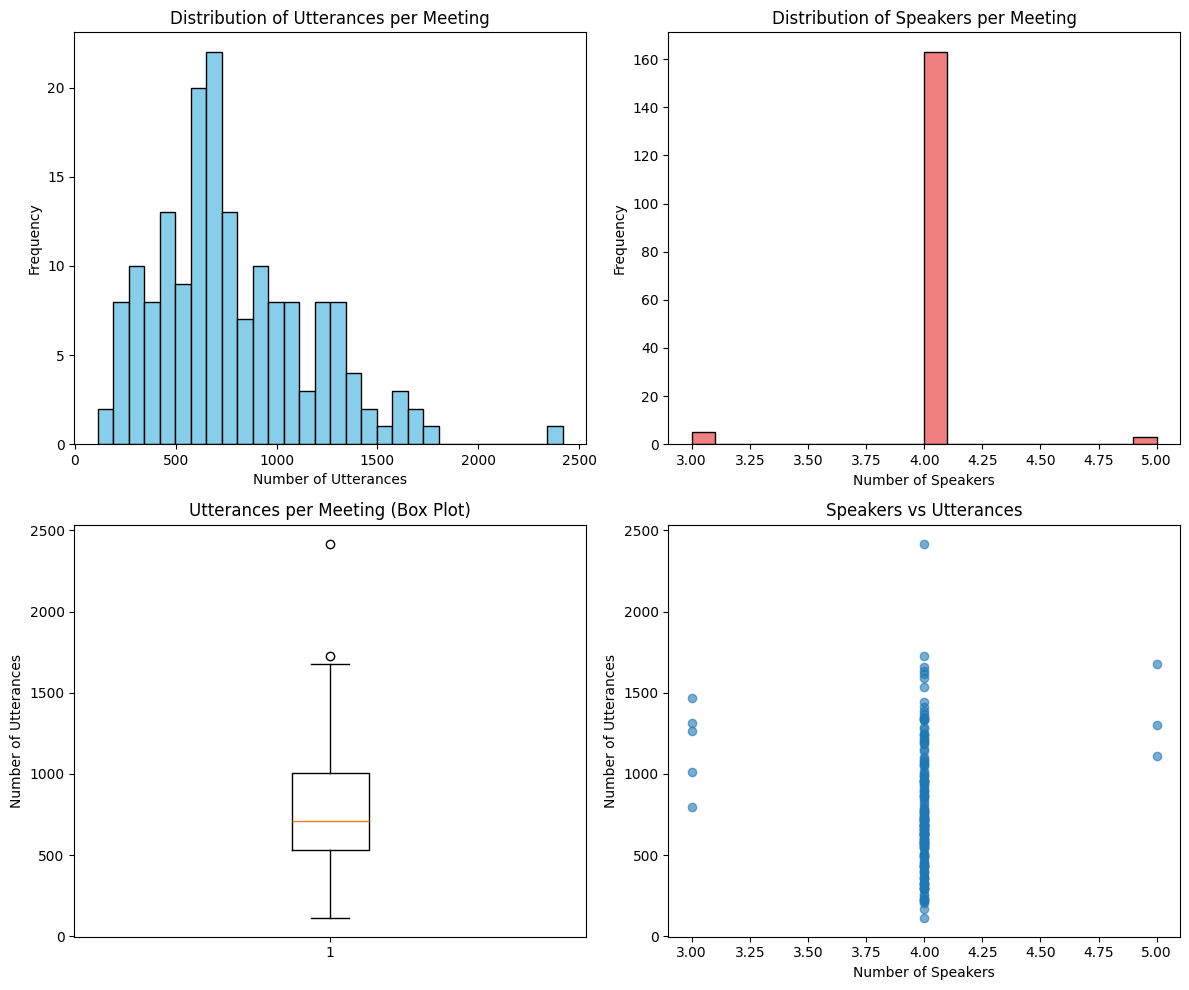

In [5]:
# Create visualizations
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Distribution of utterances per meeting
axes[0, 0].hist(df_stats['num_utterances'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Utterances per Meeting')
axes[0, 0].set_xlabel('Number of Utterances')
axes[0, 0].set_ylabel('Frequency')

# 2. Distribution of speakers per meeting
axes[0, 1].hist(df_stats['num_speakers'], bins=20, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribution of Speakers per Meeting')
axes[0, 1].set_xlabel('Number of Speakers')
axes[0, 1].set_ylabel('Frequency')

# 3. Box plot of utterances
axes[1, 0].boxplot(df_stats['num_utterances'])
axes[1, 0].set_title('Utterances per Meeting (Box Plot)')
axes[1, 0].set_ylabel('Number of Utterances')

# 4. Scatter plot: Speakers vs Utterances
axes[1, 1].scatter(df_stats['num_speakers'], df_stats['num_utterances'], alpha=0.6)
axes[1, 1].set_title('Speakers vs Utterances')
axes[1, 1].set_xlabel('Number of Speakers')
axes[1, 1].set_ylabel('Number of Utterances')

plt.tight_layout()
plt.show()

### Data Dictionary Variables

Our defined data dictionary requires these variables [1]:
- **meeting_id** (String): Unique meeting identifier
- **speaker_id** (String): Speaker identifier  
- **text** (String): Utterance transcript
- **begin_time** (Float): Start timestamp
- **end_time** (Float): End timestamp (estimated)

We extract these variables from our 171 transcript files for detailed analysis.

In [6]:
import pandas as pd
import numpy as np

# Extract data dictionary variables from transcript files
utterance_data = []

for file in transcript_files:
    file_path = os.path.join(data_folder, file)
    meeting_id = file.replace('_transcript.txt', '')
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split('|')
        if len(parts) >= 3:
            utterance_data.append({
                'meeting_id': meeting_id,
                'speaker_id': parts[0],
                'begin_time': float(parts[1]),
                'text': parts[2],
                'end_time': float(parts[1]) + 3.0  # Estimated 3-second duration
            })

# Create DataFrame with data dictionary variables
df_utterances = pd.DataFrame(utterance_data)
print(f"✓ Extracted {len(df_utterances):,} utterances with data dictionary variables")
print(f"\nSample records:")
print(df_utterances.head())

✓ Extracted 134,243 utterances with data dictionary variables

Sample records:
  meeting_id speaker_id   begin_time  \
0    EN2001a     MEO069  3302.969971   
1    EN2001a     MEE068  4149.149902   
2    EN2001a     MEE067  3192.899902   
3    EN2001a     MEO069  1455.150024   
4    EN2001a     MEE067  4781.270020   

                                                text     end_time  
0  IF YOU IF YOU S. S. H. AND THEY HAVE THIS BIG ...  3305.969971  
1                          I'VE GOTTEN MM HARDLY ANY  4152.149902  
2  IT'S YEAH I MEAN THE WAVE DATA ARE OBVIOUSLY N...  3195.899902  
3  YEAH IT'LL IT'LL PLAY THEM IN SOME ORDER IN WH...  1458.150024  
4                                               YEAH  4784.270020  


### Correlation Analysis

To understand relationships between meeting characteristics, we create meeting-level numerical features and compute their correlations [2]. This reveals patterns that inform our decision density, redundancy, and action item clarity metrics [1].

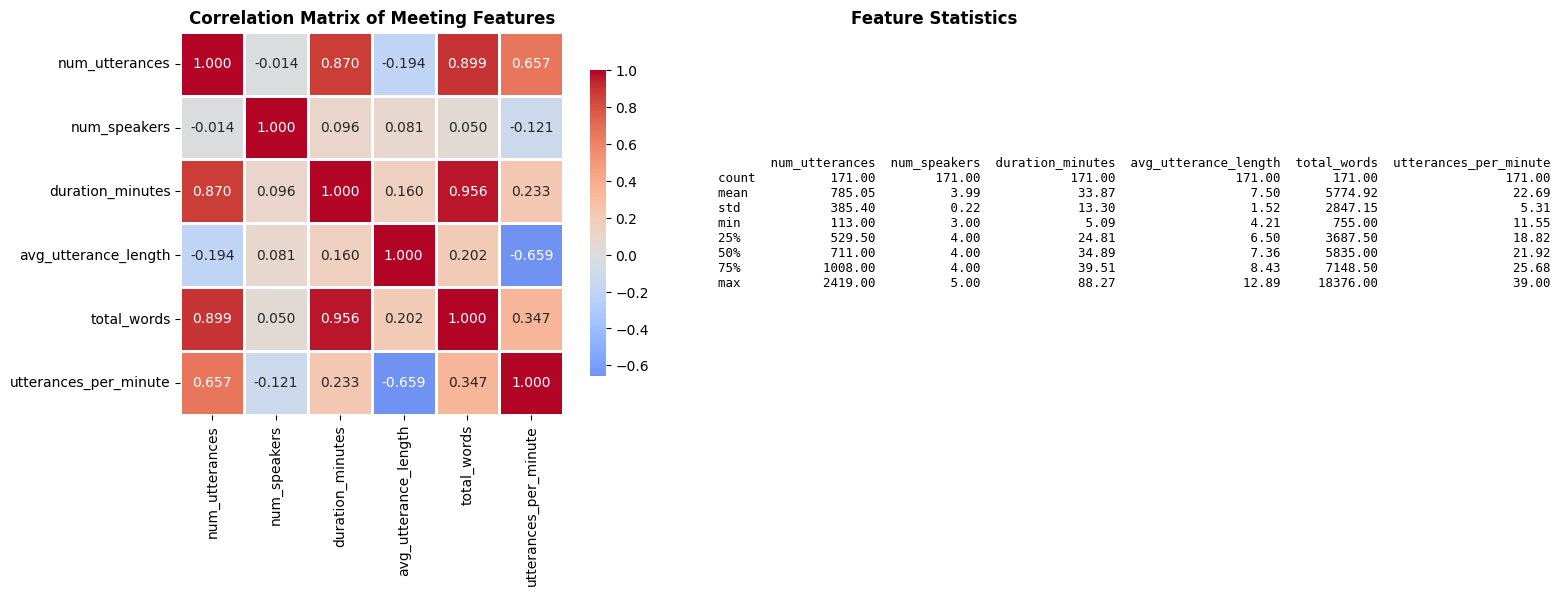


=== Strong Correlations (|r| > 0.7) ===
num_utterances ↔ duration_minutes: 0.870
num_utterances ↔ total_words: 0.899
duration_minutes ↔ total_words: 0.956


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create meeting-level features for correlation analysis
meeting_features = []

for meeting in df_utterances['meeting_id'].unique():
    meeting_data = df_utterances[df_utterances['meeting_id'] == meeting]
    timestamps = meeting_data['begin_time'].values
    texts = meeting_data['text'].values
    
    meeting_features.append({
        'num_utterances': len(meeting_data),
        'num_speakers': meeting_data['speaker_id'].nunique(),
        'duration_minutes': (timestamps.max() - timestamps.min()) / 60 if len(timestamps) > 1 else 0,
        'avg_utterance_length': np.mean([len(t.split()) for t in texts]),
        'total_words': sum([len(t.split()) for t in texts]),
        'utterances_per_minute': len(meeting_data) / ((timestamps.max() - timestamps.min()) / 60) 
            if len(timestamps) > 1 and timestamps.max() > timestamps.min() else 0
    })

df_features = pd.DataFrame(meeting_features)

# Compute correlation matrix
correlation_matrix = df_features.corr()

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, ax=ax1, cbar_kws={"shrink": 0.8})
ax1.set_title('Correlation Matrix of Meeting Features', fontsize=12, fontweight='bold')

# Descriptive statistics
ax2.axis('off')
stats_text = df_features.describe().round(2).to_string()
ax2.text(0.1, 0.5, stats_text, fontsize=9, family='monospace', va='center')
ax2.set_title('Feature Statistics', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== Strong Correlations (|r| > 0.7) ===")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            print(f"{correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {corr_value:.3f}")